# Feature Scaling (Normalization)

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0, 1, 2])
df.columns=['Class label', 'Alcohol', 'Mallic acid']

In [37]:
df.shape

(178, 3)

In [12]:
df.sample(5)

,Class label,Alcohol,Mallic acid
102,2,12.34,2.45
7,1,14.06,2.15
107,2,12.72,1.75
169,3,13.40,4.60
56,1,14.22,1.70


<Axes: xlabel='Alcohol', ylabel='Density'>

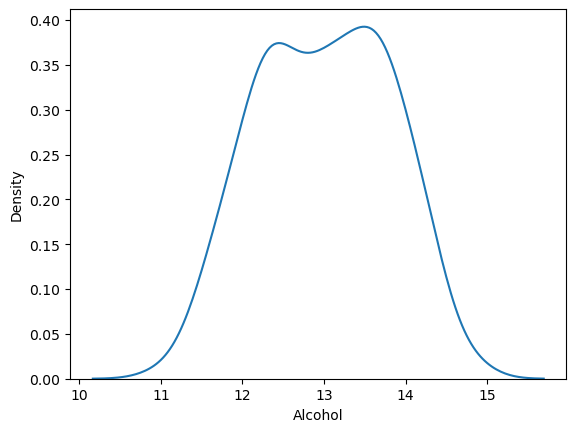

In [13]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Mallic acid', ylabel='Density'>

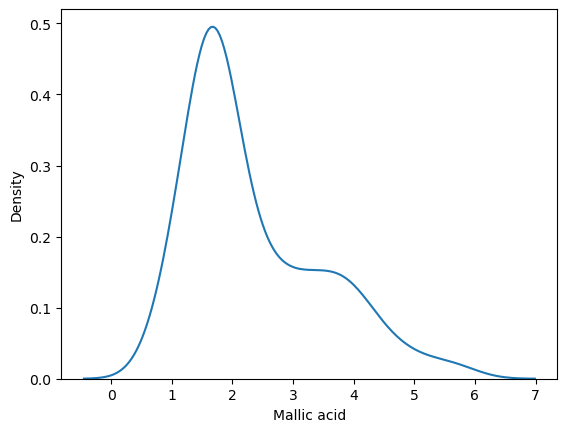

In [15]:
sns.kdeplot(df['Mallic acid'])

<Axes: xlabel='Alcohol', ylabel='Mallic acid'>

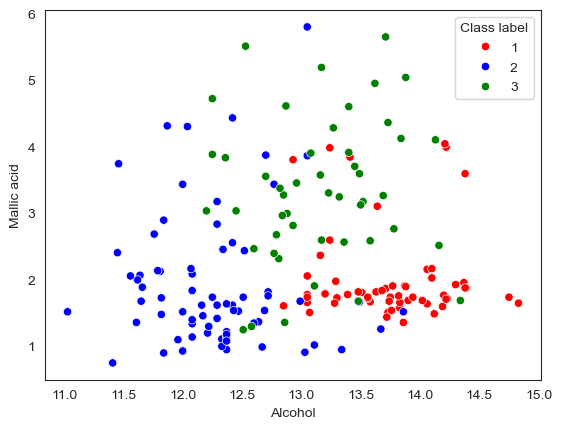

In [96]:
sns.set_style('white')
color_dict={1:'red', 3:'green', 2:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Mallic acid'], hue=df['Class label'],palette=color_dict)

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), df['Class label'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#fit the scaler to the train set, it'll learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
type(X_train_scaled) #so need to convert into pandas dataframe

numpy.ndarray

In [49]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [50]:
type(X_train_scaled)

pandas.core.frame.DataFrame

In [54]:
np.round(X_train.describe(), 1)

,Alcohol,Mallic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [53]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Mallic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


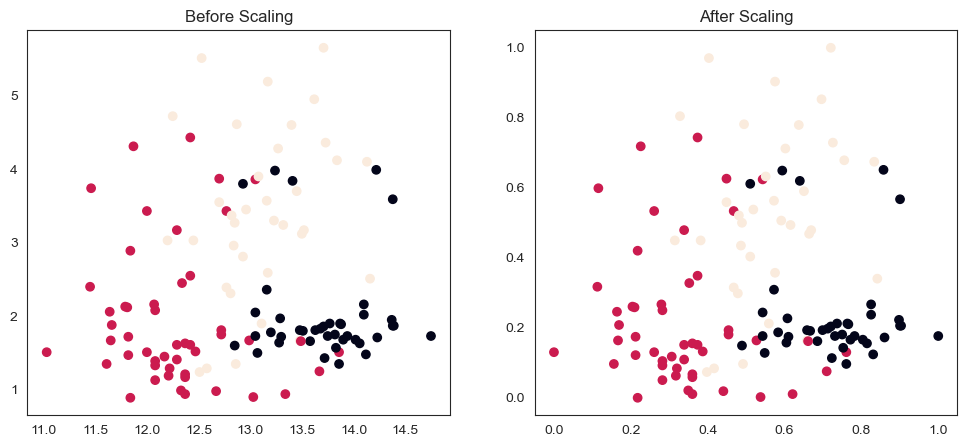

In [97]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(x=X_train['Alcohol'], y=X_train['Mallic acid'], c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(x=X_train_scaled['Alcohol'], y=X_train_scaled['Mallic acid'], c=y_train)
ax2.set_title("After Scaling")
plt.show()

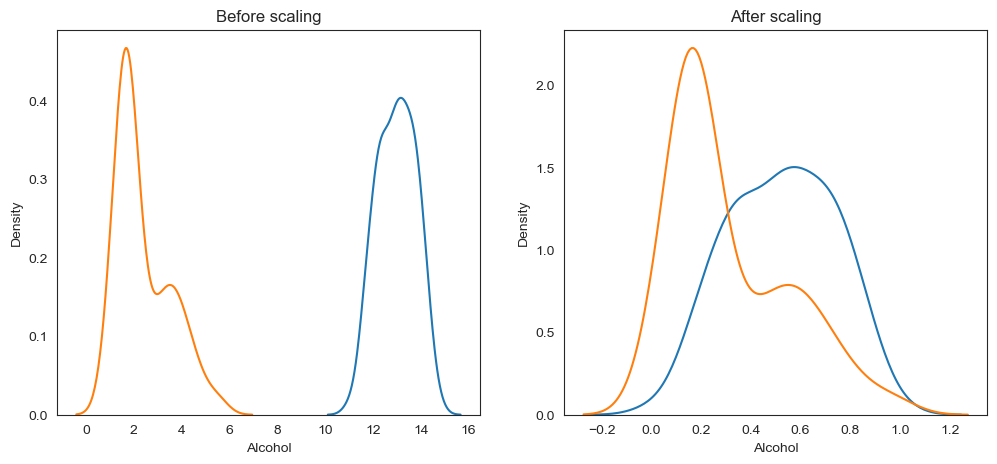

In [98]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

#before scaling
ax1.set_title('Before scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Mallic acid'], ax=ax1)

#after scaling
ax2.set_title('After scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Mallic acid'], ax=ax2)
plt.show()

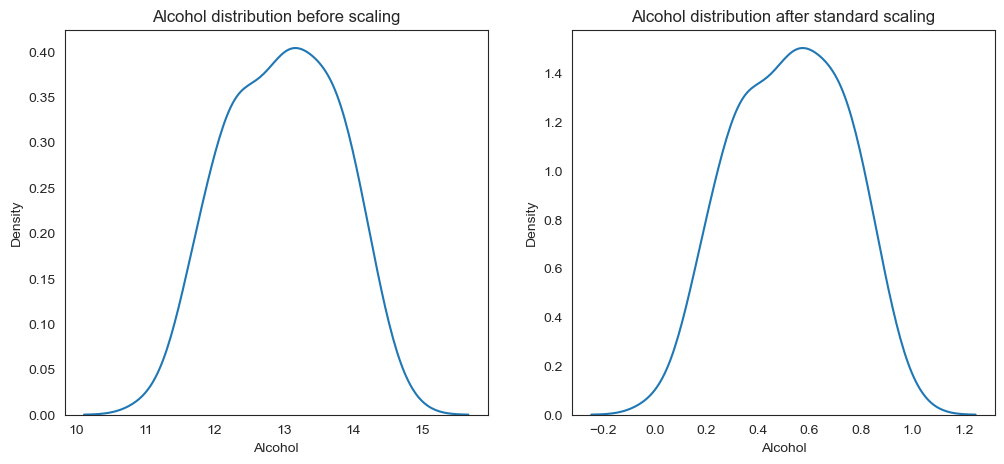

In [100]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
#before scaling
ax1.set_title("Alcohol distribution before scaling")
sns.kdeplot(X_train['Alcohol'], ax=ax1)
#after scaling
ax2.set_title("Alcohol distribution after standard scaling")
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

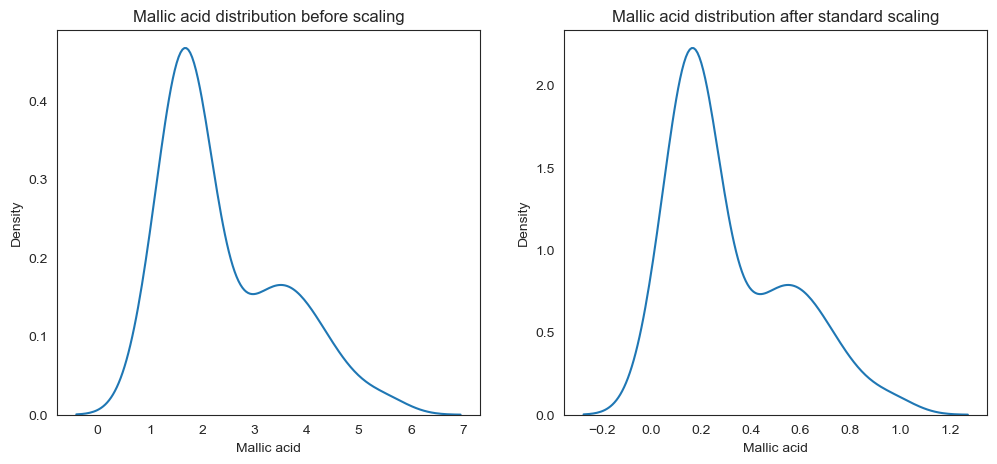

In [102]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
#before scaling
ax1.set_title("Mallic acid distribution before scaling")
sns.kdeplot(X_train['Mallic acid'], ax=ax1)
#after scaling
ax2.set_title("Mallic acid distribution after standard scaling")
sns.kdeplot(X_train_scaled['Mallic acid'], ax=ax2)
plt.show()